# Notebook 01 — Exploration des données (EDA)

**Projet** : Classification automatique de produits pour une marketplace française  
**Contexte** : Étude de cas appliquée au métier de Data Scientist Marketplace chez ADEO  
**Dataset** : Rakuten France Multimodal Product Data Classification ([source](https://challengedata.ens.fr/challenges/35))

---

## Objectifs de ce notebook

1. Comprendre la structure et la volumétrie du dataset
2. Identifier les enjeux de qualité de données typiques d'une marketplace
3. Analyser la distribution de la cible et ses implications pour la modélisation
4. Dégager des hypothèses business transposables au contexte ADEO

In [1]:
"""
ADEO Marketplace — Classification automatique de produits
Notebook 01 : Exploration des données (EDA)

Dataset : Rakuten France Multimodal Product Data Classification
Source  : https://challengedata.ens.fr/challenges/35
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Config affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid", context="notebook")

# Chemins
DATA_DIR = Path("../data")
X_PATH = DATA_DIR / "X_train_update.csv"
Y_PATH = DATA_DIR / "Y_train_CVw08PX.csv"

print("Setup OK")
print(f"X path : {X_PATH.resolve()}")
print(f"Y path : {Y_PATH.resolve()}")
print(f"X exists: {X_PATH.exists()}")
print(f"Y exists: {Y_PATH.exists()}")

Setup OK
X path : C:\Users\kaism\OneDrive\Documents\Projet Perso\Adeo-marketplace-classification\Data\X_train_update.csv
Y path : C:\Users\kaism\OneDrive\Documents\Projet Perso\Adeo-marketplace-classification\Data\Y_train_CVw08PX.csv
X exists: True
Y exists: True


In [2]:
# Chargement des features (X) et de la cible (Y)
X = pd.read_csv(X_PATH, index_col=0)
Y = pd.read_csv(Y_PATH, index_col=0)

print(f"Shape X : {X.shape}")
print(f"Shape Y : {Y.shape}")
print(f"\nColonnes X : {list(X.columns)}")
print(f"Colonnes Y : {list(Y.columns)}")

# Vérification que les index correspondent (ordre des lignes X ↔ Y)
assert (X.index == Y.index).all(), "❌ Les index de X et Y ne correspondent pas"
print("\n✅ Index X et Y alignés")

# Fusion en un seul DataFrame de travail
df = X.join(Y)
print(f"\nShape df fusionné : {df.shape}")
print(f"Colonnes df : {list(df.columns)}")

Shape X : (84916, 4)
Shape Y : (84916, 1)

Colonnes X : ['designation', 'description', 'productid', 'imageid']
Colonnes Y : ['prdtypecode']

✅ Index X et Y alignés

Shape df fusionné : (84916, 5)
Colonnes df : ['designation', 'description', 'productid', 'imageid', 'prdtypecode']


## 1. Vue d'ensemble du dataset

Premier coup d'œil sur la structure : volumétrie, types de colonnes, exemples de lignes, statistiques globales.

In [3]:
# Premier aperçu : 5 premières lignes
print("=" * 80)
print("APERÇU DES 5 PREMIÈRES LIGNES")
print("=" * 80)
display(df.head())

# Types des colonnes et valeurs non-nulles
print("\n" + "=" * 80)
print("INFOS GÉNÉRALES (df.info)")
print("=" * 80)
df.info()

APERÇU DES 5 PREMIÈRES LIGNES


,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris -...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style,PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt),NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'a...,278535884,1077757786,2705



INFOS GÉNÉRALES (df.info)
<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB


In [4]:
# Stats descriptives sur toutes les colonnes (numériques et catégorielles)
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 80)
display(df.describe(include="all").T)

# Synthèse rapide : valeurs manquantes par colonne
print("\n" + "=" * 80)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 80)
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().sum() / len(df) * 100).round(2)
})
display(missing)

STATISTIQUES DESCRIPTIVES


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
designation,84916,82265,5d Broderie Peintures Strass Diamant Bricolage Pasted Peinture Point De Croix,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,55116,47506,<br>Attention !!! Ce produit est un import si les informations 'langues' et 'sous-titres' n'app...,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productid,84916.0,NaN,NaN,NaN,2555468184.92058,1588655642.122009,183912.0,676051881.25,3190506128.5,3995598773.5,4252011632.0
imageid,84916.0,NaN,NaN,NaN,1152690961.888537,175142749.288382,67284.0,1056268739.75,1213353832.0,1275645533.25,1328824385.0
prdtypecode,84916.0,NaN,NaN,NaN,1773.2199,788.179885,10.0,1281.0,1920.0,2522.0,2905.0



VALEURS MANQUANTES PAR COLONNE


,n_missing,pct_missing
designation,0,0.00
description,29800,35.09
productid,0,0.00
imageid,0,0.00
prdtypecode,0,0.00


## 2. Analyse de la cible : `prdtypecode`

La variable à prédire est `prdtypecode`, un code numérique identifiant la catégorie produit dans la taxonomie Rakuten. 

Cette section vise à :
- Quantifier le nombre de classes
- Visualiser leur distribution (équilibrée ou non ?)
- En déduire les **métriques d'évaluation appropriées** pour la modélisation

In [5]:
# Nombre de classes uniques
n_classes = df["prdtypecode"].nunique()
print(f"Nombre de classes uniques : {n_classes}")

# Distribution brute
class_counts = df["prdtypecode"].value_counts().sort_values(ascending=False)
print(f"\nCode de la classe la plus représentée : {class_counts.index[0]} ({class_counts.iloc[0]} produits)")
print(f"Code de la classe la moins représentée : {class_counts.index[-1]} ({class_counts.iloc[-1]} produits)")

# Ratio de déséquilibre
imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[-1]
print(f"\nRatio max/min : {imbalance_ratio:.1f}x")
print(f"→ La classe majoritaire est {imbalance_ratio:.0f}x plus représentée que la minoritaire.")

# Stats sur la distribution
print(f"\nStats sur le nombre de produits par classe :")
display(class_counts.describe().to_frame("n_produits_par_classe").T)

Nombre de classes uniques : 27

Code de la classe la plus représentée : 2583 (10209 produits)
Code de la classe la moins représentée : 1180 (764 produits)

Ratio max/min : 13.4x
→ La classe majoritaire est 13x plus représentée que la minoritaire.

Stats sur le nombre de produits par classe :


,count,mean,std,min,25%,50%,75%,max
n_produits_par_classe,27.0,3145.037037,2103.248906,764.0,1551.0,2671.0,4767.0,10209.0


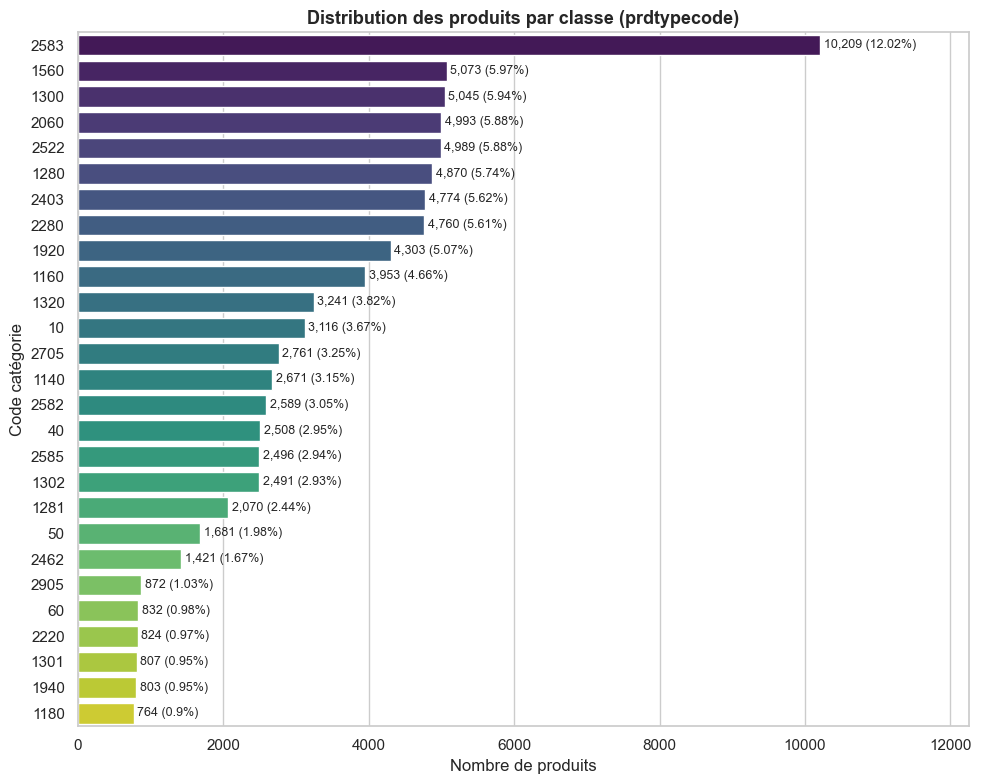

In [6]:
# Préparation des données pour le plot
class_counts_df = class_counts.reset_index()
class_counts_df.columns = ["prdtypecode", "n_produits"]
class_counts_df["prdtypecode"] = class_counts_df["prdtypecode"].astype(str)  # str pour catégoriel
class_counts_df["pct"] = (class_counts_df["n_produits"] / len(df) * 100).round(2)

# Plot horizontal trié
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=class_counts_df,
    y="prdtypecode",
    x="n_produits",
    palette="viridis",
    ax=ax,
    hue="prdtypecode",
    legend=False,
)
ax.set_title("Distribution des produits par classe (prdtypecode)", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de produits")
ax.set_ylabel("Code catégorie")
# Annotations : valeur à droite de chaque barre
for i, (count, pct) in enumerate(zip(class_counts_df["n_produits"], class_counts_df["pct"])):
    ax.text(count + 50, i, f"{count:,} ({pct}%)", va="center", fontsize=9)
ax.set_xlim(0, class_counts_df["n_produits"].max() * 1.2)
plt.tight_layout()
plt.show()

## 3. Analyse de `designation` (titre produit)

`designation` est le titre court du produit. C'est la seule feature texte **toujours renseignée** (0 valeur manquante). 

On regarde ici sa longueur (caractères et mots) et quelques exemples extrêmes pour comprendre la variabilité de saisie côté vendeur.

In [7]:
# Longueur en caractères et en mots
df["designation_n_chars"] = df["designation"].str.len()
df["designation_n_words"] = df["designation"].str.split().str.len()

# Stats descriptives
print("Stats longueur designation (caractères) :")
display(df["designation_n_chars"].describe().to_frame().T)

print("\nStats longueur designation (mots) :")
display(df["designation_n_words"].describe().to_frame().T)

Stats longueur designation (caractères) :


,count,mean,std,min,25%,50%,75%,max
designation_n_chars,84916.0,70.163303,36.793383,11.0,43.0,64.0,90.0,250.0



Stats longueur designation (mots) :


,count,mean,std,min,25%,50%,75%,max
designation_n_words,84916.0,11.557374,6.207966,3.0,7.0,11.0,14.0,56.0


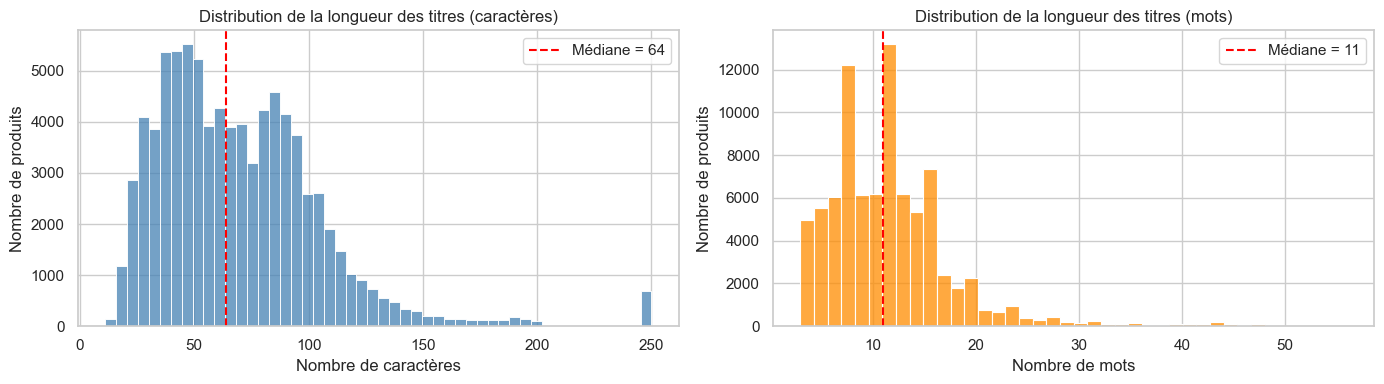

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme caractères
sns.histplot(df["designation_n_chars"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de la longueur des titres (caractères)")
axes[0].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Nombre de produits")
axes[0].axvline(df["designation_n_chars"].median(), color="red", linestyle="--", label=f"Médiane = {df['designation_n_chars'].median():.0f}")
axes[0].legend()

# Histogramme mots
sns.histplot(df["designation_n_words"], bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution de la longueur des titres (mots)")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Nombre de produits")
axes[1].axvline(df["designation_n_words"].median(), color="red", linestyle="--", label=f"Médiane = {df['designation_n_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print("=" * 80)
print("3 TITRES LES PLUS COURTS")
print("=" * 80)
display(df.nsmallest(3, "designation_n_chars")[["designation", "designation_n_chars", "prdtypecode"]])

print("\n" + "=" * 80)
print("3 TITRES LES PLUS LONGS")
print("=" * 80)
display(df.nlargest(3, "designation_n_chars")[["designation", "designation_n_chars", "prdtypecode"]])

3 TITRES LES PLUS COURTS


,designation,designation_n_chars,prdtypecode
26343,D - Livre 1,11,2705
82669,Petit 4 X 4,11,1140
14013,Fifa 12 Ps 3,12,2462



3 TITRES LES PLUS LONGS


,designation,designation_n_chars,prdtypecode
169,Action Francaise (L') N° 287 Du 15/10/1923 - L'agonie De L'evolutionnisme Par Leon Daudet - Expl...,250,2280
499,Moniteur Universel (Le) N° 56 Du 25/02/1853 - Partie Officielle - Presentation Des Lettres Qui C...,250,2280
517,T7j Yannick Noah 3p/ Star Wars 1p/ Jean Pierre Michael Ris 1p/ Ophelie Winter 4p/ Dominic Monagh...,250,2280


### Observations

- Designation toujours renseignée (0 NaN)
- Médiane et dispersion à reporter ci-dessus
- Variabilité forte entre titres très courts (qualité douteuse) et très longs (souvent saturés de mots-clés SEO)

## 4. Analyse de `description` (description longue)

Contrairement à `designation`, la `description` est :
- Souvent manquante (35% de NaN)
- Contient du HTML brut et des entités non décodées
- Parfois dupliquée (templates vendeurs)

Cette section quantifie ces problèmes et regarde si certaines catégories sont plus impactées que d'autres.

In [10]:
# Indicateur binaire : description présente ou non
df["has_description"] = df["description"].notna()

# Stats globales
pct_with = df["has_description"].mean() * 100
print(f"Produits AVEC description : {df['has_description'].sum():,} ({pct_with:.2f}%)")
print(f"Produits SANS description : {(~df['has_description']).sum():,} ({100 - pct_with:.2f}%)")

# Taux de description manquante PAR CATÉGORIE
missing_by_class = (
    df.groupby("prdtypecode")["has_description"]
    .agg(["sum", "count"])
    .assign(pct_with_desc=lambda x: (x["sum"] / x["count"] * 100).round(2))
    .assign(pct_missing=lambda x: (100 - x["pct_with_desc"]).round(2))
    .sort_values("pct_missing", ascending=False)
)
missing_by_class.columns = ["n_with_desc", "n_total", "pct_with_desc", "pct_missing"]
print("\nTaux de description manquante par classe (triées du pire au meilleur) :")
display(missing_by_class)

Produits AVEC description : 55,116 (64.91%)
Produits SANS description : 29,800 (35.09%)

Taux de description manquante par classe (triées du pire au meilleur) :


,n_with_desc,n_total,pct_with_desc,pct_missing
prdtypecode,,,,
2403,126,4774,2.64,97.36
2462,53,1421,3.73,96.27
2280,320,4760,6.72,93.28
1160,349,3953,8.83,91.17
10,338,3116,10.85,89.15
1180,153,764,20.03,79.97
40,866,2508,34.53,65.47
1140,945,2671,35.38,64.62
2705,1736,2761,62.88,37.12


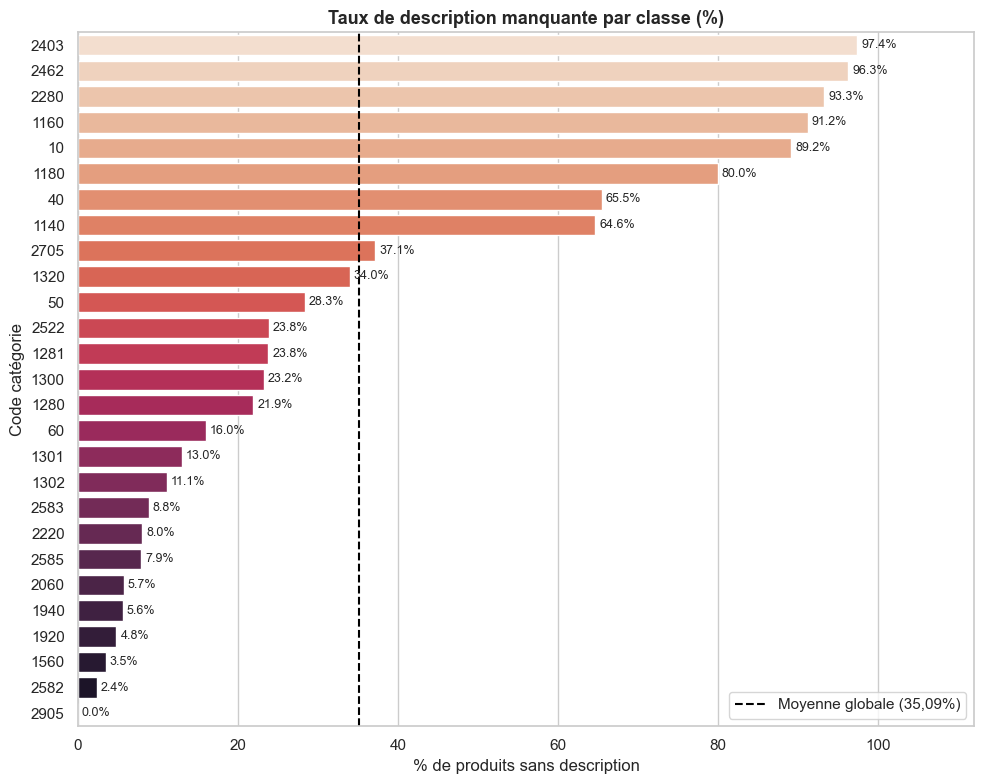

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
missing_plot = missing_by_class.reset_index()
missing_plot["prdtypecode"] = missing_plot["prdtypecode"].astype(str)

sns.barplot(
    data=missing_plot,
    y="prdtypecode",
    x="pct_missing",
    palette="rocket_r",
    ax=ax,
    hue="prdtypecode",
    legend=False,
)
ax.axvline(35.09, color="black", linestyle="--", label="Moyenne globale (35,09%)")
ax.set_title("Taux de description manquante par classe (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("% de produits sans description")
ax.set_ylabel("Code catégorie")
ax.legend()
for i, pct in enumerate(missing_plot["pct_missing"]):
    ax.text(pct + 0.5, i, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, missing_plot["pct_missing"].max() * 1.15)
plt.tight_layout()
plt.show()

Stats longueur description (caractères, descriptions non-vides uniquement) :


,count,mean,std,min,25%,50%,75%,max
description_n_chars,55116.0,808.171692,805.462153,1.0,259.0,626.0,1034.0,12451.0



Stats longueur description (mots, descriptions non-vides uniquement) :


,count,mean,std,min,25%,50%,75%,max
description_n_words,55116.0,123.510959,123.158437,1.0,39.0,95.0,161.0,2068.0


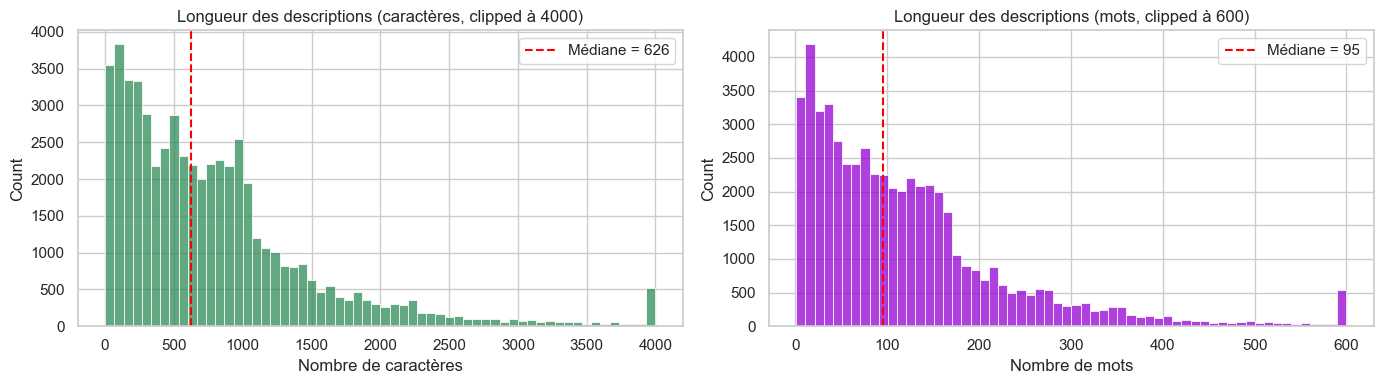

In [12]:
# Longueur uniquement sur les descriptions non-nulles
df["description_n_chars"] = df["description"].str.len()
df["description_n_words"] = df["description"].str.split().str.len()

desc_non_null = df.loc[df["has_description"], ["description_n_chars", "description_n_words"]]

print("Stats longueur description (caractères, descriptions non-vides uniquement) :")
display(desc_non_null["description_n_chars"].describe().to_frame().T)

print("\nStats longueur description (mots, descriptions non-vides uniquement) :")
display(desc_non_null["description_n_words"].describe().to_frame().T)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(desc_non_null["description_n_chars"].clip(upper=4000), bins=60, ax=axes[0], color="seagreen")
axes[0].set_title("Longueur des descriptions (caractères, clipped à 4000)")
axes[0].set_xlabel("Nombre de caractères")
axes[0].axvline(desc_non_null["description_n_chars"].median(), color="red", linestyle="--", label=f"Médiane = {desc_non_null['description_n_chars'].median():.0f}")
axes[0].legend()

sns.histplot(desc_non_null["description_n_words"].clip(upper=600), bins=60, ax=axes[1], color="darkviolet")
axes[1].set_title("Longueur des descriptions (mots, clipped à 600)")
axes[1].set_xlabel("Nombre de mots")
axes[1].axvline(desc_non_null["description_n_words"].median(), color="red", linestyle="--", label=f"Médiane = {desc_non_null['description_n_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Détection HTML dans les descriptions
sample = df.loc[df["has_description"], "description"]
n_with_html = sample.str.contains(r"<[^>]+>", regex=True, na=False).sum()
n_with_entities = sample.str.contains(r"&[a-z]+;|&#\d+;", regex=True, na=False).sum()

print(f"Descriptions contenant des balises HTML (<br>, <p>, etc.) : {n_with_html:,} ({n_with_html / len(sample) * 100:.2f}%)")
print(f"Descriptions contenant des entités HTML (&eacute;, &amp;, etc.) : {n_with_entities:,} ({n_with_entities / len(sample) * 100:.2f}%)")

# Top descriptions dupliquées (templates vendeurs)
print("\nTop 5 descriptions les plus dupliquées :")
top_duplicates = sample.value_counts().head(5)
for i, (desc, count) in enumerate(top_duplicates.items(), 1):
    print(f"\n[{i}] {count} occurrences")
    print(f"    {desc[:200]}{'...' if len(desc) > 200 else ''}")

Descriptions contenant des balises HTML (<br>, <p>, etc.) : 15,645 (28.39%)
Descriptions contenant des entités HTML (&eacute;, &amp;, etc.) : 35,029 (63.56%)

Top 5 descriptions les plus dupliquées :

[1] 252 occurrences
    <br>Attention !!! Ce produit est un import  si les informations 'langues' et 'sous-titres' n'apparaissent pas sur cette fiche produit c'est que l'éditeur ne nous les a pas fournies. Néanmoins dans la ...

[2] 232 occurrences
    Taille: En format A5 (144 cm x 21 cm) Caractéistique: -Excellente durabilité avec couverture solide design. 96 pages jaune pale (recto et verso) -Texture de papier de haute qualitévous pouvez y érire ...

[3] 189 occurrences
    Taille: En format A5 (144 cm x 21 cm) Caracteristique: -Excellente durabilite avec couverture solide design. 96 pages jaune pale (recto et verso) -Texture de papier de haute qualite:  ecrire facilemen...

[4] 162 occurrences
    Taille: En format A5 (144 cm x 21 cm) Caract?istique: -Excellente durabilit?avec couvert

### Observations

- 35% de descriptions manquantes au global, mais répartition très hétérogène par classe (à voir)
- Présence massive de HTML brut et d'entités non décodées → preprocessing texte indispensable
- Templates vendeurs dupliqués → bruit lexical à éventuellement filtrer
- Distribution de longueur très étalée → on clippera dans la visu uniquement

## 5. Analyse croisée : longueur du texte disponible par classe

On combine ici `designation` et `description` pour mesurer la **quantité totale de signal textuel** disponible par produit, puis on agrège par classe.

Objectif : identifier les classes où le modèle aura peu de matière pour apprendre.

In [14]:
# Champ texte combiné : titre + description (description vide remplacée par chaîne vide)
df["text"] = (
    df["designation"].fillna("") + " " + df["description"].fillna("")
).str.strip()

# Longueur totale (caractères et mots) du texte disponible
df["text_n_chars"] = df["text"].str.len()
df["text_n_words"] = df["text"].str.split().str.len()

print("Stats longueur texte total (designation + description) :")
display(df[["text_n_chars", "text_n_words"]].describe().T)

Stats longueur texte total (designation + description) :


,count,mean,std,min,25%,50%,75%,max
text_n_chars,84916.0,595.345471,762.319937,11.0,65.0,314.0,904.0,12536.0
text_n_words,84916.0,91.724010,116.318779,3.0,11.0,48.0,137.0,2078.0


In [15]:
# Stats agrégées par classe
text_by_class = (
    df.groupby("prdtypecode")
    .agg(
        n_produits=("text", "count"),
        median_chars=("text_n_chars", "median"),
        median_words=("text_n_words", "median"),
        pct_desc_missing=("has_description", lambda x: (1 - x.mean()) * 100),
    )
    .round(2)
    .sort_values("median_words", ascending=True)
)

print("Statistiques de longueur de texte par classe (triées du + pauvre au + riche) :")
display(text_by_class)

Statistiques de longueur de texte par classe (triées du + pauvre au + riche) :


,n_produits,median_chars,median_words,pct_desc_missing
prdtypecode,,,,
10,3116,48.0,8.0,89.15
40,2508,46.0,8.0,65.47
1180,764,53.0,9.0,79.97
2462,1421,47.0,9.0,96.27
2403,4774,54.0,10.0,97.36
1160,3953,54.0,10.0,91.17
1140,2671,61.0,11.0,64.62
2280,4760,91.0,16.0,93.28
2522,4989,247.0,38.0,23.83


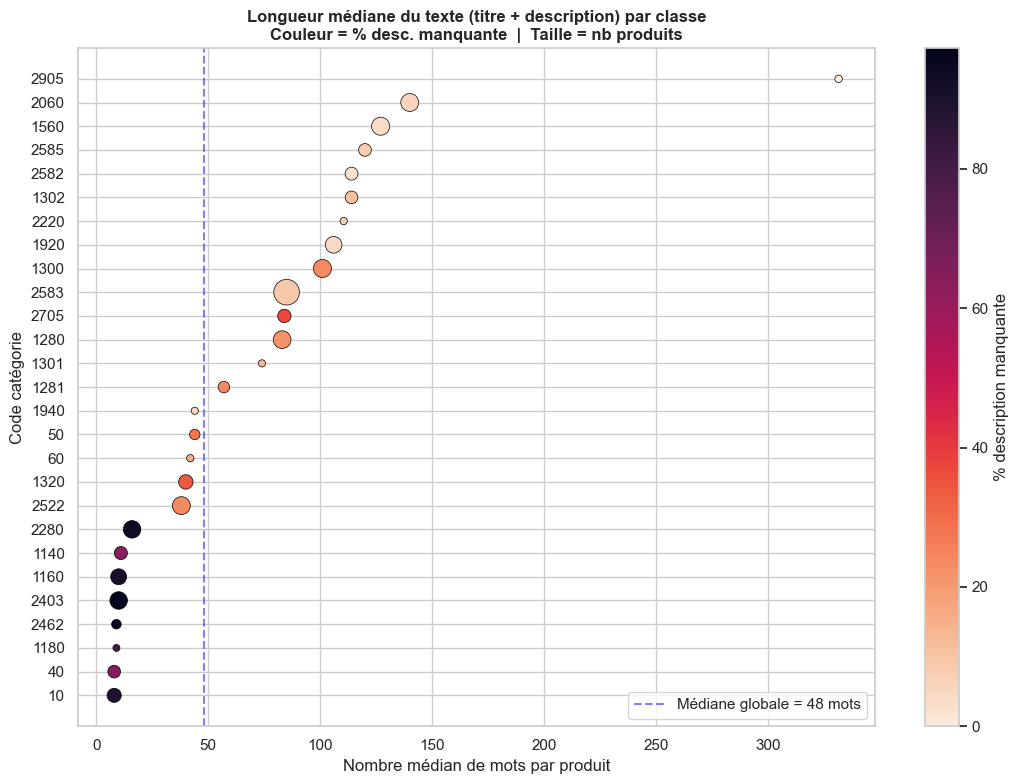

In [16]:
# Plot : longueur médiane (mots) par classe, colorée par taux de description manquante
fig, ax = plt.subplots(figsize=(11, 8))
plot_data = text_by_class.reset_index()
plot_data["prdtypecode"] = plot_data["prdtypecode"].astype(str)

scatter = ax.scatter(
    plot_data["median_words"],
    plot_data["prdtypecode"],
    c=plot_data["pct_desc_missing"],
    cmap="rocket_r",
    s=plot_data["n_produits"] / 30,  # taille proportionnelle au nb de produits
    edgecolors="black",
    linewidths=0.5,
)
ax.set_title(
    "Longueur médiane du texte (titre + description) par classe\n"
    "Couleur = % desc. manquante  |  Taille = nb produits",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Nombre médian de mots par produit")
ax.set_ylabel("Code catégorie")
ax.axvline(df["text_n_words"].median(), color="blue", linestyle="--", alpha=0.5, label=f"Médiane globale = {df['text_n_words'].median():.0f} mots")
ax.legend()

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("% description manquante")

plt.tight_layout()
plt.show()

### Observations

- Forte corrélation entre % de description manquante et faible longueur médiane de texte (sans surprise)
- Les classes "pauvres en texte" (~10-20 mots médian) reposeront uniquement sur le titre → difficulté de classification accrue
- Les classes "riches en texte" (>150 mots médian) bénéficieront pleinement de TF-IDF + embeddings

## 6. Vocabulaire discriminant par classe

On regarde ici les mots les plus fréquents par catégorie après un nettoyage léger du texte. 

Si chaque classe a un vocabulaire suffisamment distinct, un modèle simple type TF-IDF + LogReg devrait déjà obtenir de bons résultats, sans nécessiter d'embeddings sémantiques sophistiqués.

In [17]:
import re
import unicodedata
import html

def clean_text(text: str) -> str:
    """
    Preprocessing léger pour l'EDA.
    NB : Cette fonction sera reprise et complétée dans le notebook 02 pour la modélisation.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Décoder les entités HTML (&eacute; → é, &amp; → &)
    text = html.unescape(text)
    
    # 2. Supprimer les balises HTML (<br>, <p>, etc.)
    text = re.sub(r"<[^>]+>", " ", text)
    
    # 3. Normaliser les accents : é → e, à → a (robustesse aux encodages cassés)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    
    # 4. Lowercase
    text = text.lower()
    
    # 5. Garder uniquement lettres, chiffres et espaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # 6. Normaliser les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Test rapide
test_samples = [
    "<br>Attention !!! Caract&eacute;ristique : durabilit&eacute; ",
    "Caract?istique - durabilit?avec",
    "5d Broderie Peintures Strass Diamant Bricolage",
]
for s in test_samples:
    print(f"AVANT : {s}")
    print(f"APRÈS : {clean_text(s)}")
    print()

AVANT : <br>Attention !!! Caract&eacute;ristique : durabilit&eacute; 
APRÈS : attention caracteristique durabilite

AVANT : Caract?istique - durabilit?avec
APRÈS : caract istique durabilit avec

AVANT : 5d Broderie Peintures Strass Diamant Bricolage
APRÈS : 5d broderie peintures strass diamant bricolage



In [18]:
# Application du nettoyage sur le texte combiné
# /!\ Peut prendre 20-40 secondes sur 85k lignes en CPU - normal
from time import time

t0 = time()
df["text_clean"] = df["text"].apply(clean_text)
print(f"Nettoyage terminé en {time() - t0:.1f}s")

# Aperçu
print("\nExemples avant/après :")
for idx in [0, 2, 4]:
    print(f"\n[{idx}] AVANT : {df.loc[idx, 'text'][:150]}...")
    print(f"     APRÈS : {df.loc[idx, 'text_clean'][:150]}...")

Nettoyage terminé en 7.5s

Exemples avant/après :

[0] AVANT : Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design...
     APRÈS : olivia personalisiertes notizbuch 150 seiten punktraster ca din a5 rosen design...

[2] AVANT : Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour G...
     APRÈS : grand stylet ergonomique bleu gamepad nintendo wii u speedlink pilot style pilot style touch pen de marque speedlink est 1 stylet ergonomique pour gam...

[4] AVANT : La Guerre Des Tuques Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'arranger pour en &ecirc;tre le vai...
     APRÈS : la guerre des tuques luc a des idees de grandeur il veut organiser un jeu de guerre de boules de neige et s arranger pour en etre le vainqueur inconte...


In [19]:
from collections import Counter

# Stopwords français basiques (on ne sort pas l'artillerie lourde NLTK ici)
STOPWORDS_FR = {
    "le", "la", "les", "un", "une", "des", "de", "du", "et", "ou", "a", "au", "aux",
    "ce", "cet", "cette", "ces", "qui", "que", "quoi", "dont", "ou",
    "il", "elle", "ils", "elles", "on", "nous", "vous", "je", "tu", "se", "sa", "son", "ses",
    "mon", "ma", "mes", "ton", "ta", "tes", "notre", "votre", "leur", "leurs",
    "pour", "par", "avec", "sans", "sous", "sur", "dans", "vers", "chez", "entre",
    "est", "sont", "etait", "etaient", "ete", "etre", "avoir", "avait", "avaient",
    "fait", "faire", "plus", "moins", "tres", "tout", "tous", "toute", "toutes",
    "aussi", "alors", "comme", "si", "non", "oui", "ne", "pas", "rien",
    "en", "y", "d", "l", "n", "s", "t", "m", "j", "c", "qu",
    # quelques anglais qui apparaissent
    "the", "and", "of", "to", "in", "for", "is", "on", "with", "by",
    # bruit numérique
    "1", "2", "3", "4", "5", "6", "7", "8", "9", "0",
}

def top_tokens(texts: pd.Series, n_top: int = 15, min_len: int = 2) -> list:
    """Renvoie les n_top tokens les plus fréquents, après filtrage stopwords."""
    counter = Counter()
    for text in texts:
        tokens = text.split()
        tokens = [t for t in tokens if t not in STOPWORDS_FR and len(t) >= min_len]
        counter.update(tokens)
    return counter.most_common(n_top)

In [20]:
# On choisit 6 classes représentatives :
# - 2 du Groupe 1 (pauvres en texte)
# - 2 du Groupe 2 (moyennement riches)
# - 2 du Groupe 3 (riches en texte)

sample_classes = [
    (2403, "Groupe 1 — pauvre"),
    (10,   "Groupe 1 — pauvre"),
    (2522, "Groupe 2 — moyen"),
    (1320, "Groupe 2 — moyen"),
    (1280, "Groupe 3 — riche"),
    (2583, "Groupe 3 — riche"),
]

for code, label in sample_classes:
    subset = df.loc[df["prdtypecode"] == code, "text_clean"]
    n = len(subset)
    top = top_tokens(subset, n_top=15)
    print("=" * 80)
    print(f"Classe {code}  |  {label}  |  {n:,} produits")
    print("=" * 80)
    for token, count in top:
        print(f"  {token:<20s} {count:>6,}")
    print()

Classe 2403  |  Groupe 1 — pauvre  |  4,774 produits
  lot                   1,913
  livres                  809
  tomes                   389
  volumes                 329
  tome                    302
  collection              267
  partitions              238
  revues                  218
  editions                217
  edition                 185
  vol                     173
  livre                   173
  10                      172
  numeros                 168
  histoire                165

Classe 10  |  Groupe 1 — pauvre  |  3,116 produits
  edition                 238
  tome                    166
  livre                   148
  nos                     108
  histoire                 98
  guide                    93
  occasion                 88
  prix                     87
  vendons                  82
  partenaires              82
  donnons                  82
  organisations            81
  france                   80
  ammareal                 80
  caritatives            

## 7. Sauvegarde pour la suite

On sauvegarde le DataFrame nettoyé pour qu'il soit directement réutilisable dans le notebook 02 (modélisation).

In [21]:
# Colonnes à conserver pour la modélisation
cols_to_save = [
    "designation",
    "description",
    "text",           # designation + description brut
    "text_clean",     # version nettoyée (HTML/accents/casse/ponctuation)
    "has_description", # feature binaire potentiellement utile
    "prdtypecode",    # cible
]

# Création du dossier processed/
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "df_clean.parquet"
df[cols_to_save].to_parquet(OUTPUT_PATH, index=True)

print(f"✅ DataFrame sauvegardé : {OUTPUT_PATH.resolve()}")
print(f"   Taille : {OUTPUT_PATH.stat().st_size / 1024**2:.2f} Mo")
print(f"   Shape : {df[cols_to_save].shape}")

✅ DataFrame sauvegardé : C:\Users\kaism\OneDrive\Documents\Projet Perso\Adeo-marketplace-classification\Data\processed\df_clean.parquet
   Taille : 83.44 Mo
   Shape : (84916, 6)
